In [3]:
import pandas as pd

df = pd.read_csv('ULTERA_aggregated_ctpp.csv', index_col=0)
df

,composition,temperature,VAM,CW,HIP,SPS,A,BCC,FCC,HCP,...,compressive ductility,compressive yield stress,d parameter,density,hardness,tensile ductility,tensile yield stress,ultimate compressive strength,ultimate tensile strength,youngs modulus
0,Al0.1Cr1Fe1Co1Ni1,0.099333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.500000,1.198000e+09,NaN,NaN,NaN
1,Al0.1Cr1Fe1Co1Ni1,0.099333,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,24.633333,8.233333e+08,NaN,928000000.0,NaN
2,Al0.25Cr1Fe1Co1Ni1,0.099333,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,1.093480e+09,NaN,NaN,NaN,NaN,NaN
3,Al0.25Cr1Fe1Co1Ni1,0.124333,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Al0.25Cr1Fe1Co1Ni1,0.200000,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1391,ZrTiNbVMo,0.099333,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,1.779000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1392,ZrTiNbVMo,0.424333,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,NaN,4.670000e+08,NaN,7.27,NaN,NaN,NaN,NaN,NaN,NaN
1393,ZrTiNbVMo,0.491000,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,NaN,1.160000e+08,NaN,7.27,NaN,NaN,NaN,NaN,NaN,NaN
1394,ZrTiNbVMo2,0.099333,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,1.765000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1112]:
df.loc[:, 'VAM':'A'].sum(axis=1)

0       1.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
1391    2.0
1392    2.0
1393    2.0
1394    2.0
1395    1.0
Length: 1396, dtype: float64

In [11]:
import re

def parse_alloy_composition(composition):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)(\d*\.?\d*)')
    matches = pattern.findall(composition)
    
    # Create a dictionary to store elements and their amounts
    elements = {}
    for element, amount in matches:
        if amount == '':
            amount = 1.0  # Default amount is 1 if not specified
        else:
            amount = float(amount)
        elements[element] = amount
    
    return elements


ele_dict = [parse_alloy_composition(it) for it in df['composition']]
print(len(ele_dict))

1396


In [12]:
ele_occurence = {}
for c in ele_dict:
    for k in c.keys():
        if k not in ele_occurence:
            ele_occurence[k] = 0
        ele_occurence[k] += 1
print(ele_occurence)

{'Al': 544, 'Cr': 684, 'Fe': 613, 'Co': 533, 'Ni': 630, 'Si': 71, 'Cu': 155, 'Mo': 418, 'V': 322, 'W': 176, 'Ge': 1, 'Pd': 5, 'Hf': 265, 'Zr': 417, 'Ta': 425, 'Nb': 698, 'Ti': 732, 'Sc': 2, 'Li': 1, 'Mg': 6, 'Zn': 10, 'Mn': 142, 'Re': 13, 'Ru': 17, 'Nd': 1, 'Y': 5}


In [1]:
import numpy as np

ele_lookup = {k: i for i, k in enumerate(sorted(ele_occurence.keys()))}
ele_arr = np.zeros([len(df), len(ele_occurence)], dtype=float)
for idx, comp in enumerate(ele_dict):
    for ele, frac in comp.items():
        ele_arr[idx, ele_lookup[ele]] = frac
ele_arr /= ele_arr.sum(axis=1).reshape(-1, 1)
print(np.percentile(np.sum(ele_arr, axis=1), [0, 100]))
df_comp = pd.DataFrame(ele_arr, columns=ele_lookup.keys())

NameError: name 'ele_occurence' is not defined

In [524]:
np.sum(df == df, axis=0)

composition                      1396
temperature                      1396
VAM                              1396
CW                               1396
HIP                              1396
SPS                              1396
A                                1396
BCC                              1396
FCC                              1396
HCP                              1396
IM                               1396
CTE                                84
compressive ductility             326
compressive yield stress          637
d parameter                        94
density                           100
hardness                          499
tensile ductility                 198
tensile yield stress              174
ultimate compressive strength     214
ultimate tensile strength         161
youngs modulus                    114
dtype: int64

In [1007]:
np.abs(df.loc[:, 'compressive ductility':'youngs modulus'].corr())

,compressive ductility,compressive yield stress,d parameter,density,hardness,tensile ductility,tensile yield stress,ultimate compressive strength,ultimate tensile strength,youngs modulus
compressive ductility,1.000000,0.657927,NaN,0.729020,0.675011,0.564894,0.501729,0.358216,0.459307,0.024546
compressive yield stress,0.657927,1.000000,NaN,0.125560,0.747641,0.617112,0.806850,0.870965,0.498881,0.287467
d parameter,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
density,0.729020,0.125560,NaN,1.000000,0.675110,NaN,NaN,0.442451,NaN,0.932617
hardness,0.675011,0.747641,NaN,0.675110,1.000000,0.803224,0.753538,0.303810,0.474307,0.091097
tensile ductility,0.564894,0.617112,NaN,NaN,0.803224,1.000000,0.519369,NaN,0.251858,0.282768
tensile yield stress,0.501729,0.806850,NaN,NaN,0.753538,0.519369,1.000000,NaN,0.810676,0.353225
ultimate compressive strength,0.358216,0.870965,NaN,0.442451,0.303810,NaN,NaN,1.000000,NaN,0.559083
ultimate tensile strength,0.459307,0.498881,NaN,NaN,0.474307,0.251858,0.810676,NaN,1.000000,0.012728
youngs modulus,0.024546,0.287467,NaN,0.932617,0.091097,0.282768,0.353225,0.559083,0.012728,1.000000


In [1127]:
from sklearn import ensemble, model_selection, preprocessing

x_columns = list(df_comp.columns) + list(df.loc[:, 'VAM':'IM'].columns) + list(df.loc[:, ['temperature']].columns)
x = np.hstack([df_comp.values, df.loc[:, 'VAM':'IM'].values, df.loc[:, ['temperature']].values])
y = df.loc[:, ['compressive yield stress', 'hardness']].values # .reshape(-1, 1)
# y = df.loc[:, ['compressive yield stress', 'hardness', 'tensile yield stress', 'ultimate compressive strength']].values
# y = df.loc[:, 'compressive yield stress'].values.reshape(-1, 1)
# y = df.loc[:, 'hardness'].values.reshape(-1, 1)

xy = np.hstack([x, y])
valid_idx = np.arange(xy.shape[0])[np.isfinite(np.sum(xy, axis=1))]

print(x.shape, y.shape, len(valid_idx))

train_idx, tv_idx = model_selection.train_test_split(valid_idx, train_size=0.60, random_state=0)
test_idx, val_idx = model_selection.train_test_split(tv_idx, train_size=0.50, random_state=0)

scaler = preprocessing.StandardScaler().fit(y[train_idx])
y = scaler.transform(y)

rf = ensemble.RandomForestRegressor(random_state=0)
_ = rf.fit(x[train_idx], y[train_idx])

(1396, 36) (1396, 2) 205


CYS (n=637)
 
MSE = 0.029, R2 = 0.971
MSE = 0.201, R2 = 0.734
MSE = 0.231, R2 = 0.737

Hardness (n=499)

MSE = 0.036, R2 = 0.964
MSE = 0.446, R2 = 0.618
MSE = 0.302, R2 = 0.762

Weighted mean:

MSE = 0.032
MSE = 0.308
MSE = 0.262

0.2621875

In [1130]:
for idx in [train_idx, val_idx, test_idx]:
    y_pred = rf.predict(x[idx])
    residual = y[idx] - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y[idx])
    print(f'MSE = {mse:.3f}, R2 = {r2:.3f}')

MSE = 0.055, R2 = 0.945
MSE = 0.329, R2 = 0.648
MSE = 0.685, R2 = 0.482


In [1115]:
# rf.fit(x[valid_idx], y[valid_idx].flatten())  # refit to all the data
rf.fit(x[train_idx], y[train_idx].flatten())
p = x[val_idx].copy()
pred = rf.predict(p)
b = np.mean(np.abs(pred - y[val_idx].flatten()))

print(f'Baseline: MAE = {b:.3f}')

fi = []
for i in range(x.shape[1]):
    mae_trials = []
    for j in range(40):
        p = x[val_idx].copy()
        np.random.shuffle(p[:, i])
        pred = rf.predict(p)
        mae = np.mean(np.abs(pred - y[val_idx].flatten()))
        mae_trials.append(mae)
    mae = np.mean(mae_trials)
    print(f'{x_columns[i]:12s}: Delta_MAE = {mae-b:.3f}')
    fi.append(mae)

Baseline: MAE = 0.314
Al          : Delta_MAE = 0.019
Co          : Delta_MAE = 0.019
Cr          : Delta_MAE = 0.018
Cu          : Delta_MAE = 0.006
Fe          : Delta_MAE = 0.021
Ge          : Delta_MAE = 0.000
Hf          : Delta_MAE = 0.008
Li          : Delta_MAE = 0.000
Mg          : Delta_MAE = 0.000
Mn          : Delta_MAE = 0.004
Mo          : Delta_MAE = 0.066
Nb          : Delta_MAE = 0.025
Nd          : Delta_MAE = 0.000
Ni          : Delta_MAE = 0.036
Pd          : Delta_MAE = 0.000
Re          : Delta_MAE = -0.000
Ru          : Delta_MAE = 0.000
Sc          : Delta_MAE = 0.001
Si          : Delta_MAE = 0.004
Ta          : Delta_MAE = 0.067
Ti          : Delta_MAE = 0.052
V           : Delta_MAE = 0.006
W           : Delta_MAE = 0.006
Y           : Delta_MAE = 0.002
Zn          : Delta_MAE = 0.000
Zr          : Delta_MAE = 0.003
VAM         : Delta_MAE = 0.025
CW          : Delta_MAE = 0.000
HIP         : Delta_MAE = 0.004
SPS         : Delta_MAE = 0.006
A           : Del

In [1116]:
thresh = 0.01
include = np.argwhere(np.array(fi-b) > thresh).flatten()
print([x_columns[it] for it in include])

['Al', 'Co', 'Cr', 'Fe', 'Mo', 'Nb', 'Ni', 'Ta', 'Ti', 'VAM', 'BCC', 'FCC', 'IM', 'temperature']


In [1121]:
x_columns = list(df_comp.columns) + list(df.loc[:, 'VAM':'IM'].columns) + list(df.loc[:, ['temperature']].columns)
x = np.hstack([df_comp.values, df.loc[:, 'VAM':'IM'].values, df.loc[:, ['temperature']].values])
y = df.loc[:, 'compressive yield stress'].values.reshape(-1, 1)

x = x[:, include]
print(x.shape, y.shape)

xy = np.hstack([x, y])
valid_idx = np.arange(xy.shape[0])[np.isfinite(np.sum(xy, axis=1))]

print(x.shape, y.shape, len(valid_idx))
print()

train_idx, tv_idx = model_selection.train_test_split(valid_idx, train_size=0.60, random_state=0)
test_idx, val_idx = model_selection.train_test_split(tv_idx, train_size=0.50, random_state=0)

scaler = preprocessing.StandardScaler().fit(y[train_idx])
y = scaler.transform(y)

rf = ensemble.RandomForestRegressor(random_state=0)
_ = rf.fit(x[train_idx], y[train_idx].flatten())

for idx in [train_idx, val_idx, test_idx]:
    y_pred = rf.predict(x[idx])
    residual = y[idx].flatten() - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y[idx].flatten())
    print(f'MSE = {mse:.3f}, R2 = {r2:.3f}')

(1396, 14) (1396, 1)
(1396, 14) (1396, 1) 637

MSE = 0.039, R2 = 0.961
MSE = 0.193, R2 = 0.743
MSE = 0.237, R2 = 0.729


In [ ]:
fig = plt.figure(figsize=(5, 2))
plt.bar(np.arange(len(fi)), fi, label='Permutation')
plt.plot([-0.5, 4.5], np.ones(2)*b, 'k--', label='Baseline')
plt.legend()
plt.ylabel('MAE')
plt.xticks(np.arange(len(fi)))

In [1213]:
df.columns

Index(['composition', 'temperature', 'VAM', 'CW', 'HIP', 'SPS', 'A', 'BCC',
       'FCC', 'HCP', 'IM', 'CTE', 'compressive ductility',
       'compressive yield stress', 'd parameter', 'density', 'hardness',
       'tensile ductility', 'tensile yield stress',
       'ultimate compressive strength', 'ultimate tensile strength',
       'youngs modulus'],
      dtype='object')

In [1214]:
df.loc[:, 'compressive ductility':].corr().loc[:, ['tensile yield stress']]

,tensile yield stress
compressive ductility,-0.501729
compressive yield stress,0.806850
d parameter,NaN
density,NaN
hardness,0.753538
tensile ductility,-0.519369
tensile yield stress,1.000000
ultimate compressive strength,NaN
ultimate tensile strength,0.810676
youngs modulus,-0.353225


In [1286]:
import torch

# y = df.loc[:, ['compressive yield stress', 'hardness']].values
# 
# y = df.loc[:, ['compressive yield stress', 'hardness', 'tensile yield stress', 'ultimate compressive strength']].values
# y = df.loc[:, ['tensile yield stress', ]].values
y = df.loc[:, ['tensile yield stress', 'ultimate tensile strength', 'compressive yield stress', 'hardness']].values

xy = np.hstack([x, y])
valid_idx = np.arange(xy.shape[0])[np.sum(np.isfinite(y), axis=1) > 0]

train_idx, tv_idx = model_selection.train_test_split(valid_idx, train_size=0.60, random_state=0)
test_idx, val_idx = model_selection.train_test_split(tv_idx, train_size=0.50, random_state=0)

scaler = preprocessing.StandardScaler().fit(y[train_idx])
y = scaler.transform(y)

x_train = torch.tensor(x[train_idx]).float()
y_train = torch.tensor(y[train_idx]).float()

x_valid = torch.tensor(x[val_idx]).float()
y_valid = torch.tensor(y[val_idx]).float()

x_test = torch.tensor(x[test_idx]).float()
y_test = torch.tensor(y[test_idx]).float()

print(x_train.shape, y_train.shape)

torch.Size([643, 36]) torch.Size([643, 4])


In [1287]:
from torch import nn, optim
import torch.nn.functional as F
import sparsenn

class MultiTaskMSELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        # Mask out the NaN values in the targets
        mask = ~torch.isnan(target)

        # Compute the mean squared error, ignoring NaN values
        mse = F.mse_loss(input[mask], target[mask], reduction='mean')

        return mse
    

input_dim = x_train.shape[1]
hidden_dim = (128, 128, 64, 64, 32, 32, )
hidden_dim = [int(h*1) for h in hidden_dim]
output_dim = y_train.shape[1]

model = sparsenn.RegularizedMLP(input_dim, hidden_dim, output_dim, activation=nn.ELU())
criterion = MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [1288]:
best_model = (None, np.inf, np.inf)

In [1289]:
from copy import deepcopy
import torch.utils

# Training loop
# best_model = (None, np.inf, np.inf)

train_loader = torch.utils.data.DataLoader(list(zip(x_train, y_train)), batch_size=2048, shuffle=True)

lmbda_reg = 1e-7
n_epoch = int(1e4)
model.train()
for epoch in range(n_epoch):
    for x_train_b, y_train_b in train_loader:
        optimizer.zero_grad()
        outputs = model(x_train_b)
        loss = criterion(outputs, y_train_b)
        reg_loss = model.regularization_loss()
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            outputs = model(x_valid)
            valid_loss = criterion(outputs, y_valid)
            outputs = model(x_test)
            test_loss = criterion(outputs, y_test)
        if valid_loss < best_model[1]:
            best_model = (deepcopy(model), valid_loss.item(), test_loss.item())
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        model.train()

Epoch 100, MSE: 0.6322, L0R: 30078.80, ValMSE: 0.4958, TestMSE: 0.6766
Epoch 200, MSE: 0.5449, L0R: 29941.75, ValMSE: 0.5675, TestMSE: 0.6740
Epoch 300, MSE: 0.5488, L0R: 29781.50, ValMSE: 0.5890, TestMSE: 0.7634
Epoch 400, MSE: 0.5353, L0R: 29648.36, ValMSE: 0.5966, TestMSE: 0.6738
Epoch 500, MSE: 0.5776, L0R: 29565.56, ValMSE: 0.7286, TestMSE: 0.7784
Epoch 600, MSE: 0.4523, L0R: 29489.77, ValMSE: 0.6353, TestMSE: 0.5893
Epoch 700, MSE: 0.4259, L0R: 29427.50, ValMSE: 0.7068, TestMSE: 0.6615
Epoch 800, MSE: 0.4069, L0R: 29352.72, ValMSE: 0.5388, TestMSE: 0.5530
Epoch 900, MSE: 0.3499, L0R: 29303.85, ValMSE: 0.4616, TestMSE: 0.5713
Epoch 1000, MSE: 0.3893, L0R: 29269.46, ValMSE: 0.4696, TestMSE: 0.6117
Epoch 1100, MSE: 0.3962, L0R: 29232.70, ValMSE: 0.4308, TestMSE: 0.6423
Epoch 1200, MSE: 0.2929, L0R: 29206.85, ValMSE: 0.3864, TestMSE: 0.4952
Epoch 1300, MSE: 0.2975, L0R: 29175.88, ValMSE: 0.3731, TestMSE: 0.6048
Epoch 1400, MSE: 0.3314, L0R: 29160.27, ValMSE: 0.3459, TestMSE: 0.5542
E

In [1290]:
print(best_model, best_model[0].regularization_loss().item())

(RegularizedMLP(
  (activation): ELU(alpha=1.0)
  (layers): ModuleList(
    (0-6): 7 x L0Linear()
  )
), 0.25923600792884827, 0.4585796594619751) 28111.138671875


In [1155]:
from sparsenn import viz

# Render the optimized architecture 
# b = best_model[0]
b = model
g = viz.gated_connections_graph(b, thresh=1e-3)
# paths, nodes = viz.find_paths_nodes(g)
# fig = viz.render_sparse_nn(g)

In [1058]:
fig = viz.render_sparse_nn(g)

KeyboardInterrupt: 

<BarContainer object of 7 artists>

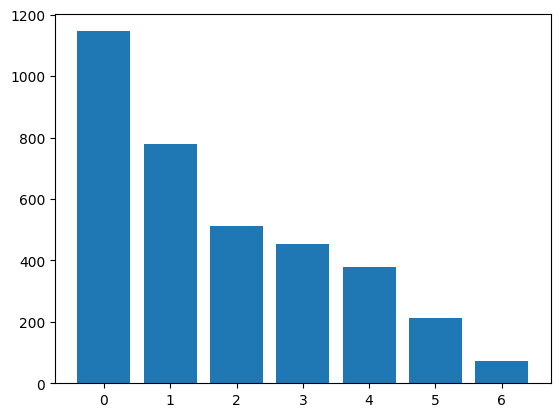

In [1156]:
b = best_model[0]
plt.bar(np.arange(len(b.layers)), [l.count_non_gated_params() for l in b.layers])

In [1291]:
rf = ensemble.RandomForestRegressor(random_state=0, criterion='squared_error')
# task 1
for dim in range(y.shape[1]):
    print(f'task {dim}')
    task_y = y_train[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_train.cpu()[sel]
    y_in = task_y[sel].flatten()
    _ = rf.fit(x_in, y_in)
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    # print(f'MSE = {mse:.3f}, R2 = {r2:.3f}')
    
    task_y = y_valid[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_valid.cpu()[sel]
    y_in = task_y[sel].flatten()
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    print(f'Val MSE  = {mse:.3f}, R2 = {r2:.3f}')
    
    task_y = y_test[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_test.cpu()[sel]
    y_in = task_y[sel].flatten()
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    print(f'Test MSE = {mse:.3f}, R2 = {r2:.3f}')

task 0
Val MSE  = 0.476, R2 = 0.266
Test MSE = 0.913, R2 = 0.223
task 1
Val MSE  = 0.256, R2 = 0.508
Test MSE = 0.367, R2 = 0.322
task 2
Val MSE  = 0.185, R2 = 0.811
Test MSE = 0.347, R2 = 0.703
task 3
Val MSE  = 0.194, R2 = 0.783
Test MSE = 0.363, R2 = 0.688


In [1292]:
# b = best_model[0]
b = model
b.eval()
with torch.no_grad():
    out_val = b(x_valid)
    out_test = b(x_test)

    for dim in range(y.shape[1]):
        print(f'task {dim}')
        residual = out_val[:, dim] - y_valid[:, dim]
        mse = np.nanmean(residual**2)
        r2 = 1 - np.nanvar(residual) / np.nanvar(y_valid[:, dim])
        print(f'Val MSE  = {mse:.3f}, R2 = {r2:.3f}')
        
        residual = out_test[:, dim] - y_test[:, dim]
        mse = np.nanmean(residual**2)
        r2 = 1 - np.nanvar(residual) / np.nanvar(y_test[:, dim])
        print(f'Test MSE = {mse:.3f}, R2 = {r2:.3f}')

task 0
Val MSE  = 0.884, R2 = -0.358
Test MSE = 1.176, R2 = -0.084
task 1
Val MSE  = 0.278, R2 = 0.399
Test MSE = 0.490, R2 = 0.293
task 2
Val MSE  = 0.158, R2 = 0.844
Test MSE = 0.391, R2 = 0.668
task 3
Val MSE  = 0.183, R2 = 0.796
Test MSE = 0.400, R2 = 0.648


In [892]:
from sparsenn import pareto

explored_values = []
frontier = []
# valid_history = []
# train_history = []

max_epochs = int(1e5)

for k in range(15, 16):
    lmbda_reg = 1e-5 * 2**k
    reg_prec = 3
    patience_interval = 1000
    last_best = 0
    model.train()
    for epoch in range(max_epochs):
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        reg_loss = model.regularization_loss()
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        optimizer.step()
    
        point = np.array([loss.item(), np.round(reg_loss.item(), reg_prec)])
        explored_values.append(point)
        if not pareto.is_dominated(point, frontier):
            # with torch.no_grad():
            #     outputs = model(x_valid)
            #     valid_loss = criterion(outputs, y_valid)
            #     valid_history.append([epoch, reg_loss.item(), loss.item(), valid_loss.item()])
                # print(f'New frontier ValMSE: {valid_loss.item():.4f}')
            frontier = pareto.update_pareto_front(point, frontier)
            last_best = epoch
    
        if reg_loss.item() < 1:
            break
    
        if (epoch+1) % 1000 == 0:
            with torch.no_grad():
                outputs = model(x_valid)
                valid_loss = criterion(outputs, y_valid)
            print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}')
            train_history.append([reg_loss.item(), loss.item(), valid_loss.item()])
        
        if epoch - last_best > patience_interval:
            print('Patience expired...')
            break
            
    # return explored_values, frontier

KeyboardInterrupt: 

Text(0, 0.5, 'Parameters')

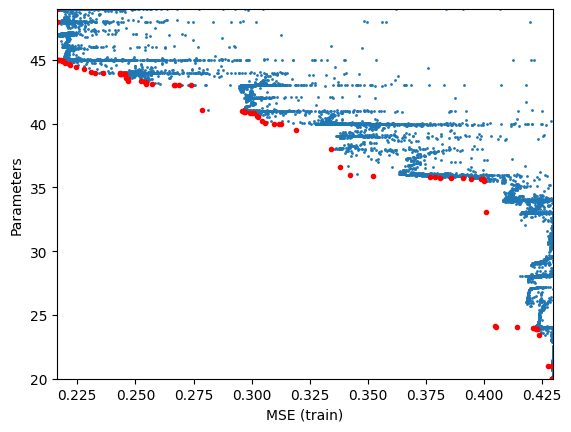

In [151]:
import matplotlib.pyplot as plt

v = np.array(explored_values)
p = np.array(frontier)
plt.scatter(*v.T, s=1, rasterized=True) 
plt.plot(p[:, 0], p[:, 1], 'r.')
plt.xlim(p[:, 0].min(), p[:, 0].max())
plt.ylim(p[:, 1].min(), p[:, 1].max())
plt.xlabel('MSE (train)')
plt.ylabel('Parameters')

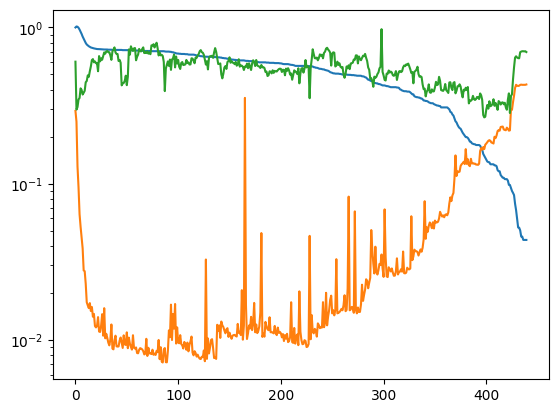

In [152]:
import matplotlib.pyplot as plt

val_traj = np.array(train_history)
plt.plot(val_traj[:, 0] / val_traj[0, 0])
plt.plot(val_traj[:, 1])
plt.plot(val_traj[:, 2])
plt.yscale('log')

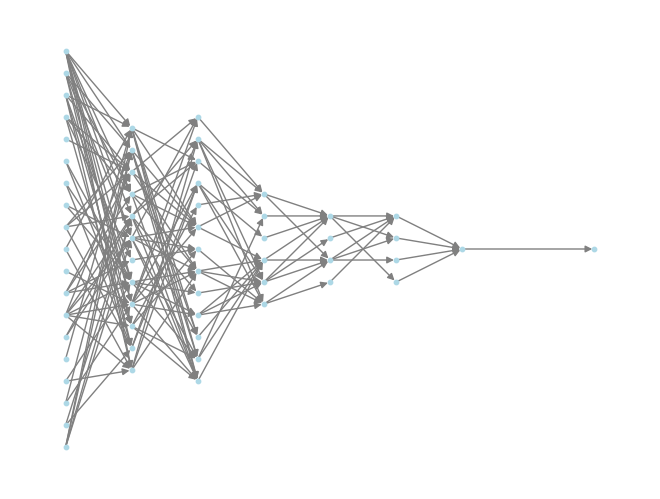

In [240]:
from sparsenn import viz

# Render the optimized architecture 
g = viz.gated_connections_graph(model) 
fig = viz.render_sparse_nn(g)

# sequential learning / cascade

In [1308]:
from sklearn import neighbors

def build_input(x_in, seq_models):
    for sm in seq_models:
        x_in = np.hstack([x_in, sm.predict(x_in).reshape(-1, 1)])
    return x_in

task_order = [2, 3, 1, 0]
# learned_outputs = np.zeros([len(y_train), 0])

rf = ensemble.RandomForestRegressor(random_state=0, criterion='squared_error')
seq_inputs = []
seq_models = []

for dim in task_order:
    print(f'task {dim}')
    task_y = y_train[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_train.cpu()[sel]
    y_in = task_y[sel].flatten()
    
    x_in = build_input(x_in, seq_models)
    
    _ = rf.fit(x_in, y_in)
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    # print(f'MSE = {mse:.3f}, R2 = {r2:.3f}')
    
    # learned_outputs = np.hstack([learned_outputs, y_pred.reshape(-1, 1)])
    # seq_models.append(deepcopy(rf))
    
    task_y = y_valid[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_valid.cpu()[sel]
    y_in = task_y[sel].flatten()
    
    x_in = build_input(x_in, seq_models)
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    print(f'Val MSE  = {mse:.3f}, R2 = {r2:.3f}')
    
    task_y = y_test[:, dim].cpu().numpy().flatten()
    sel = np.isfinite(task_y).astype(bool)
    x_in = x_test.cpu()[sel]
    y_in = task_y[sel].flatten()
    
    x_in = build_input(x_in, seq_models)
    
    y_pred = rf.predict(x_in)
    residual = y_in - y_pred
    mse = np.mean(residual**2)
    r2 = 1 - np.var(residual) / np.var(y_in)
    print(f'Test MSE = {mse:.3f}, R2 = {r2:.3f}')

    seq_models.append(deepcopy(rf))

task 2
Val MSE  = 0.185, R2 = 0.811
Test MSE = 0.347, R2 = 0.703
task 3
Val MSE  = 0.178, R2 = 0.802
Test MSE = 0.326, R2 = 0.718
task 1
Val MSE  = 0.345, R2 = 0.283
Test MSE = 0.466, R2 = 0.136
task 0
Val MSE  = 0.764, R2 = -0.010
Test MSE = 0.739, R2 = 0.261


task 2
Val MSE  = 0.185, R2 = 0.811
Test MSE = 0.347, R2 = 0.703
task 3
Val MSE  = 0.194, R2 = 0.783
Test MSE = 0.363, R2 = 0.688
task 1
Val MSE  = 0.256, R2 = 0.508
Test MSE = 0.367, R2 = 0.322
task 0
Val MSE  = 0.476, R2 = 0.266
Test MSE = 0.913, R2 = 0.223
